In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

df= pd.read_csv(r"C:\Users\shubh\Downloads\archive (1)\zomato.csv",encoding='latin-1')
country_map  = pd.read_excel(r"C:\Users\shubh\Downloads\archive (1)\Country-Code.xlsx")

In [13]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [18]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [6]:
df = df.merge(country_map,on = 'Country Code' ,how = 'left')
df[['Restaurant Name','Country Code','Country','City']].head()

,Restaurant Name,Country Code,Country,City
0,Le Petit Souffle,162,Phillipines,Makati City
1,Izakaya Kikufuji,162,Phillipines,Makati City
2,Heat - Edsa Shangri-La,162,Phillipines,Mandaluyong City
3,Ooma,162,Phillipines,Mandaluyong City
4,Sambo Kojin,162,Phillipines,Mandaluyong City


In [13]:
df.columns


Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Price range',
       'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Country_x',
       'Country_y', 'Country'],
      dtype='object')

In [ ]:
df.isnull().sum()*100/len(df)
df.drop(columns=['Switch to order menu'],inplace= True)


In [14]:
df['Cuisines']= df['Cuisines'].fillna('Not Specified')

In [24]:
country_counts = df['Country'].value_counts()
country_counts

Country
India             8652
United States      434
United Kingdom      80
Brazil              60
UAE                 60
South Africa        60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Singapore           20
Qatar               20
Sri Lanka           20
Canada               4
Name: count, dtype: int64

In [25]:
india_df = df[df['Country'] == 'India'].copy()
print(india_df.shape)

(8652, 23)


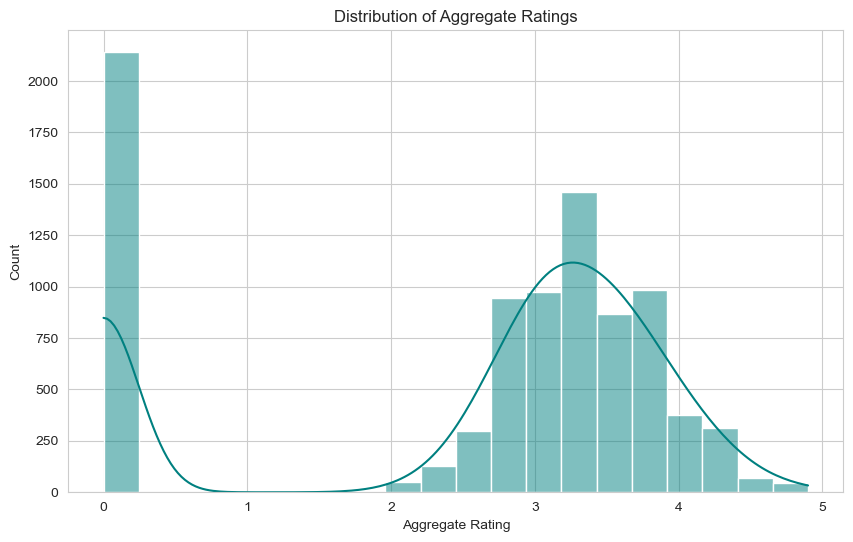

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(india_df['Aggregate rating'], bins=20, kde=True, color='teal')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.savefig('chart_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
print(india_df['Rating text'].value_counts())

Rating text
Average      3678
Not rated    2139
Good         1847
Very Good     692
Poor          180
Excellent     116
Name: count, dtype: int64


C:\Users\shubh\AppData\Local\Temp\ipykernel_38232\2626723160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Price range', data = india_df,palette = 'magma')


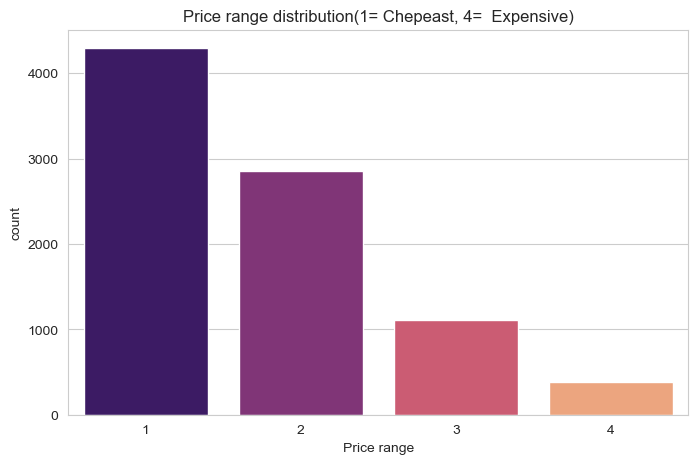

Price range
1    49.6
2    33.0
3    12.8
4     4.5
Name: proportion, dtype: float64


In [35]:
#price range distribution
plt.figure(figsize= (8,5))
sns.countplot(x='Price range', data = india_df,palette = 'magma')
plt.title('Price range distribution(1= Chepeast, 4=  Expensive)')
plt.show()
print(india_df['Price range'].value_counts(normalize=True).mul(100).round(1))


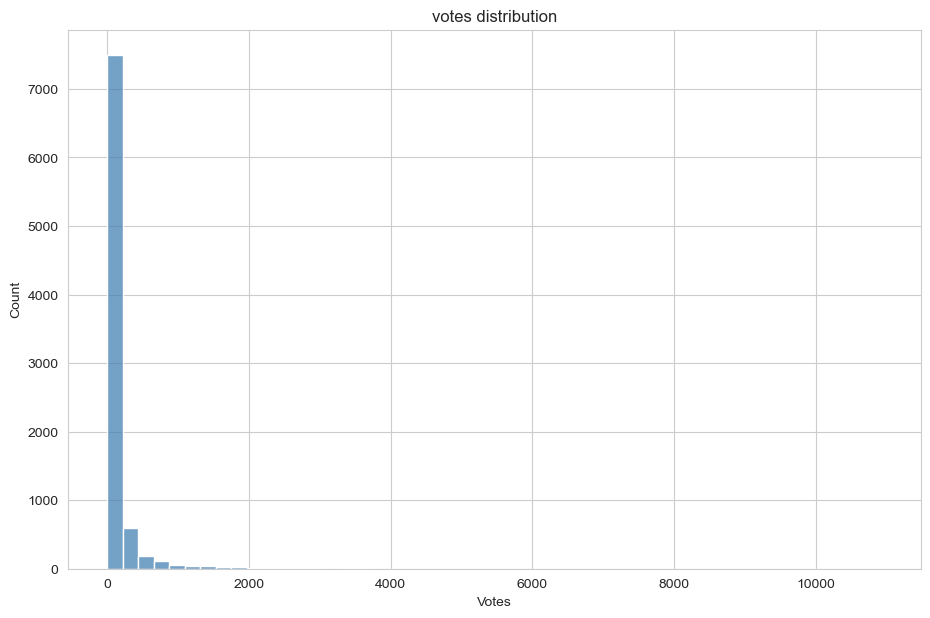

Skewness: 9.656538999220201


In [34]:
#votes distribution
plt.figure(figsize=(11,7))
sns.histplot(india_df['Votes'],bins =50,color ='steelblue')
plt.title('votes distribution')
plt.show()
print('Skewness:', india_df['Votes'].skew())

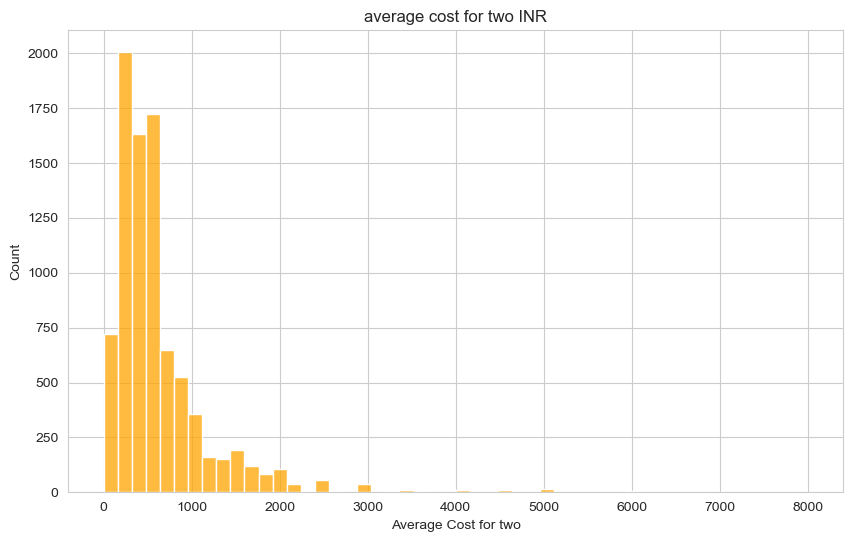

count    8652.000000
mean      623.370319
std       595.676124
min         0.000000
25%       300.000000
50%       450.000000
75%       700.000000
max      8000.000000
Name: Average Cost for two, dtype: float64

In [37]:
# average for two
plt.figure(figsize=(10,6))
sns.histplot(india_df['Average Cost for two'],bins =50 , color='orange')
plt.title('average cost for two INR')
plt.show()
india_df['Average Cost for two'].describe()

In [42]:
rated_df = india_df[india_df['Rating text'] != 'Not rated'].copy()
print('Rated restaurants:', rated_df.shape[0])
print('Average rating:', rated_df['Aggregate rating'].mean())

Rated restaurants: 6513
Average rating: 3.3520343927529557


In [49]:
# top rated
top_rated = rated_df[rated_df['Votes']>100].sort_values('Aggregate rating', ascending=False)
top_rated[['Restaurant Name', 'City', 'Cuisines', 'Aggregate rating', 'Votes']].head(10)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes
2414,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,5966
2536,Barbeque Nation,Nagpur,"North Indian, European, Mediterranean",4.9,226
748,Sagar Gaire Fast Food,Bhopal,Fast Food,4.9,427
3601,Indian Accent - The Manor,New Delhi,Modern Indian,4.9,1934
3013,Naturals Ice Cream,New Delhi,Ice Cream,4.9,2620
841,CakeBee,Coimbatore,"Bakery, Desserts",4.9,200
2418,Grandson of Tunday Kababi,Lucknow,"Mughlai, Lucknowi",4.9,1057
2301,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,200
4298,Masala Library,New Delhi,Modern Indian,4.9,408
2409,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,1753


C:\Users\shubh\AppData\Local\Temp\ipykernel_38232\3604387508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_rating.values, y=city_rating.index, palette='crest')


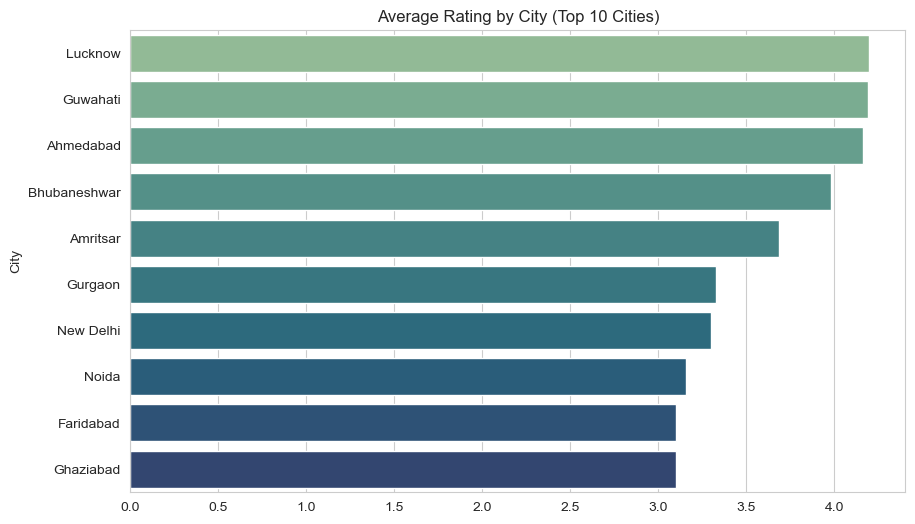

City
Lucknow         4.195238
Guwahati        4.190476
Ahmedabad       4.161905
Bhubaneshwar    3.980952
Amritsar        3.685714
Gurgaon         3.330674
New Delhi       3.297381
Noida           3.159626
Faridabad       3.103311
Ghaziabad       3.100000
Name: Aggregate rating, dtype: float64

In [50]:
#average rating in a citry
top_cities = india_df['City'].value_counts().head(10).index

city_rating = (rated_df[rated_df['City'].isin(top_cities)]
                .groupby('City')['Aggregate rating'].mean()
                .sort_values(ascending=False))

plt.figure(figsize=(10,6))
sns.barplot(x=city_rating.values, y=city_rating.index, palette='crest')
plt.title('Average Rating by City (Top 10 Cities)')
plt.show()

city_rating

C:\Users\shubh\AppData\Local\Temp\ipykernel_38232\2580608611.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_cost.values, y=city_cost.index, palette='flare')


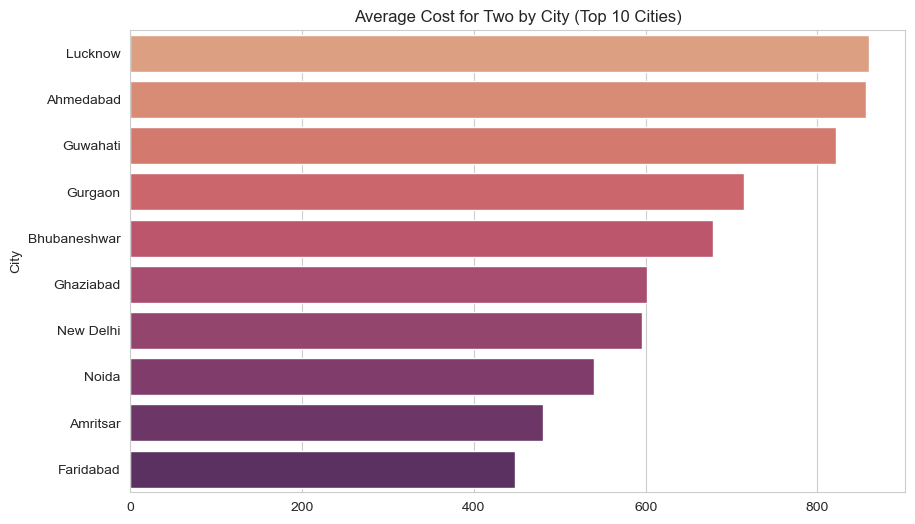

City
Lucknow         859.523810
Ahmedabad       857.142857
Guwahati        821.428571
Gurgaon         714.016100
Bhubaneshwar    678.571429
Ghaziabad       602.000000
New Delhi       596.088069
Noida           539.490741
Amritsar        480.952381
Faridabad       447.609562
Name: Average Cost for two, dtype: float64

In [51]:
#average cost in a city
city_cost = (india_df[india_df['City'].isin(top_cities)]
              .groupby('City')['Average Cost for two'].mean()
              .sort_values(ascending=False))

plt.figure(figsize=(10,6))
sns.barplot(x=city_cost.values, y=city_cost.index, palette='flare')
plt.title('Average Cost for Two by City (Top 10 Cities)')
plt.show()

city_cost

C:\Users\shubh\AppData\Local\Temp\ipykernel_38232\2296779685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Price range', y='Aggregate rating', data=rated_df, palette='magma')


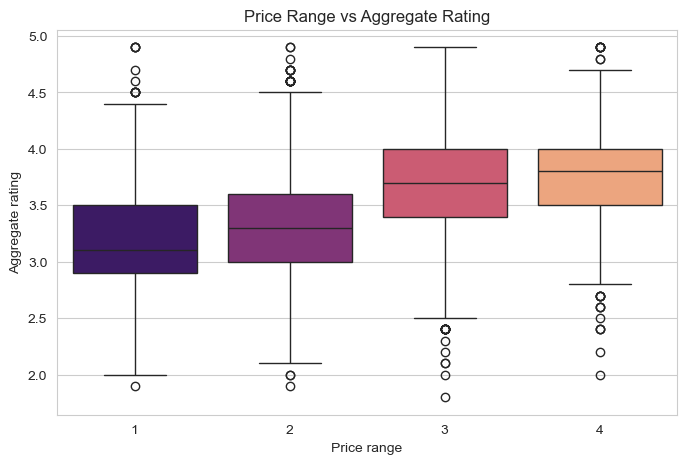

Correlation: 0.359


In [57]:
#price range related to rating
plt.figure(figsize=(8,5))
sns.boxplot(x='Price range', y='Aggregate rating', data=rated_df, palette='magma')
plt.title('Price Range vs Aggregate Rating')
plt.show()

corr = rated_df['Price range'].corr(rated_df['Aggregate rating'])
print('Correlation:', round(corr, 3))

C:\Users\shubh\AppData\Local\Temp\ipykernel_38232\3298233223.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cuisine Count', data=india_df, palette='Blues_d')


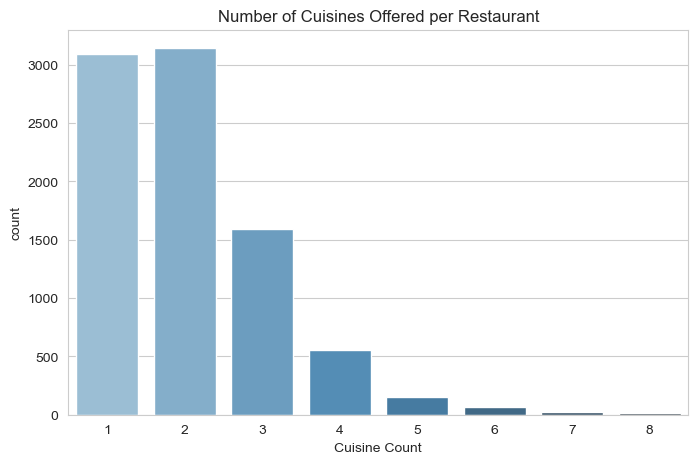

Cuisine Count
1    3097
2    3144
3    1596
4     552
5     155
6      70
7      26
8      12
Name: count, dtype: int64

In [58]:
#cuisine offer by each restaurant
india_df['Cuisine Count'] = india_df['Cuisines'].apply(lambda x: len(x.split(',')))

plt.figure(figsize=(8,5))
sns.countplot(x='Cuisine Count', data=india_df, palette='Blues_d')
plt.title('Number of Cuisines Offered per Restaurant')
plt.show()

india_df['Cuisine Count'].value_counts().sort_index()

In [60]:
cuisines_exploded = india_df.assign(
    Cuisines=india_df['Cuisines'].str.split(',')
).explode('Cuisines')

cuisines_exploded['Cuisines'] = cuisines_exploded['Cuisines'].str.strip()

cuisines_exploded[['Restaurant Name', 'Cuisines']].head(10)

,Restaurant Name,Cuisines
624,Jahanpanah,North Indian
624,Jahanpanah,Mughlai
625,Rangrezz Restaurant,North Indian
625,Rangrezz Restaurant,Mughlai
626,Time2Eat - Mama Chicken,North Indian
627,Chokho Jeeman Marwari Jain Bhojanalya,Rajasthani
628,Pinch Of Spice,North Indian
628,Pinch Of Spice,Chinese
628,Pinch Of Spice,Mughlai
629,MoMo Cafe,North Indian


C:\Users\shubh\AppData\Local\Temp\ipykernel_38232\3378055690.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='YlOrRd_r')


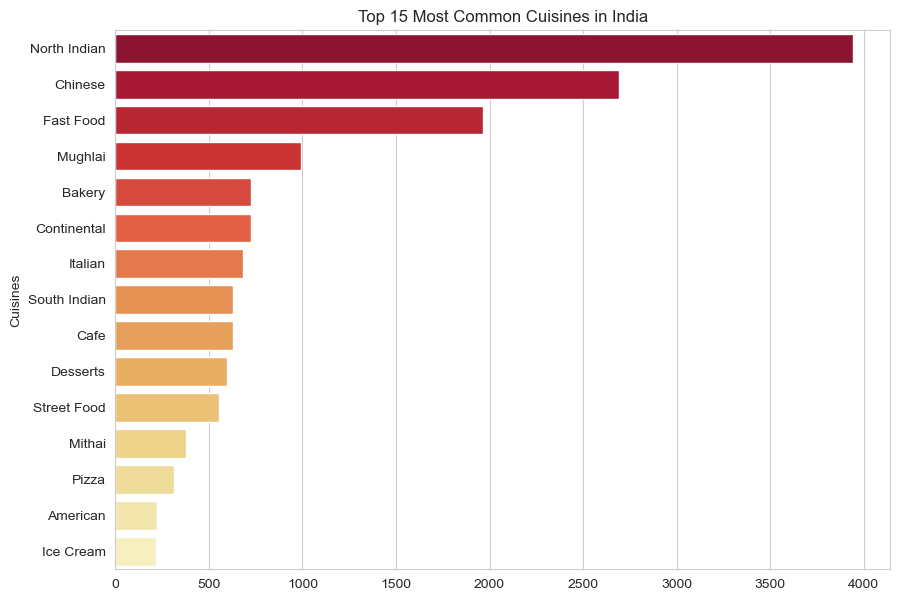

Cuisines
North Indian    3946
Chinese         2690
Fast Food       1963
Mughlai          992
Bakery           726
Continental      724
Italian          682
South Indian     631
Cafe             627
Desserts         597
Street Food      554
Mithai           380
Pizza            313
American         225
Ice Cream        216
Name: count, dtype: int64

In [61]:
# top cuisine
top_cuisines = cuisines_exploded['Cuisines'].value_counts().head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='YlOrRd_r')
plt.title('Top 15 Most Common Cuisines in India')
plt.show()

top_cuisines

C:\Users\shubh\AppData\Local\Temp\ipykernel_38232\406291161.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index, palette='RdYlGn')


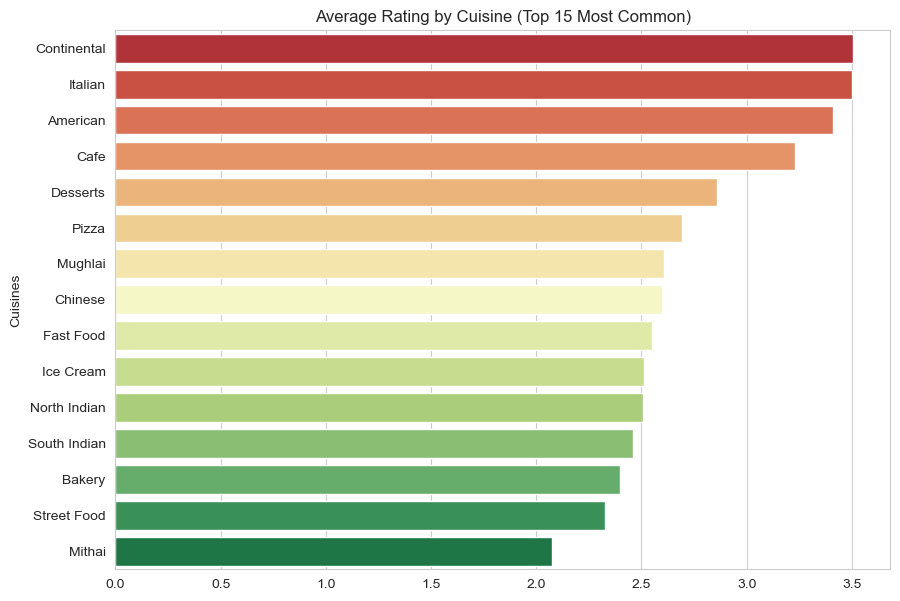

Cuisines
Continental     3.507873
Italian         3.500587
American        3.412000
Cafe            3.232057
Desserts        2.858794
Pizza           2.693291
Mughlai         2.605444
Chinese         2.598885
Fast Food       2.549720
Ice Cream       2.512500
North Indian    2.505170
South Indian    2.458954
Bakery          2.397107
Street Food     2.328881
Mithai          2.073684
Name: Aggregate rating, dtype: float64

In [62]:
# highest rated cuiseine
top_cuisine_list = top_cuisines.index.tolist()

cuisine_rating = (cuisines_exploded[cuisines_exploded['Cuisines'].isin(top_cuisine_list)]
                   .groupby('Cuisines')['Aggregate rating'].mean()
                   .sort_values(ascending=False))

plt.figure(figsize=(10,7))
sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index, palette='RdYlGn')
plt.title('Average Rating by Cuisine (Top 15 Most Common)')
plt.show()

cuisine_rating

C:\Users\shubh\AppData\Local\Temp\ipykernel_38232\2808114889.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15_cities.values, y=top15_cities.index, palette='mako')


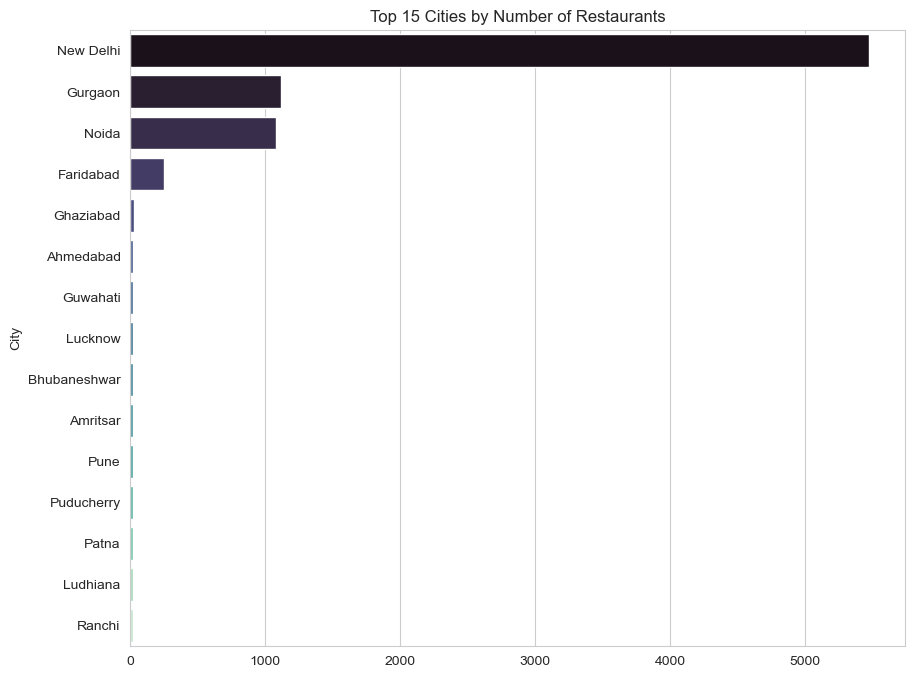

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Guwahati          21
Lucknow           21
Bhubaneshwar      21
Amritsar          21
Pune              20
Puducherry        20
Patna             20
Ludhiana          20
Ranchi            20
Name: count, dtype: int64

In [63]:
top15_cities = india_df['City'].value_counts().head(15)

plt.figure(figsize=(10,8))
sns.barplot(x=top15_cities.values, y=top15_cities.index, palette='mako')
plt.title('Top 15 Cities by Number of Restaurants')
plt.show()

top15_cities

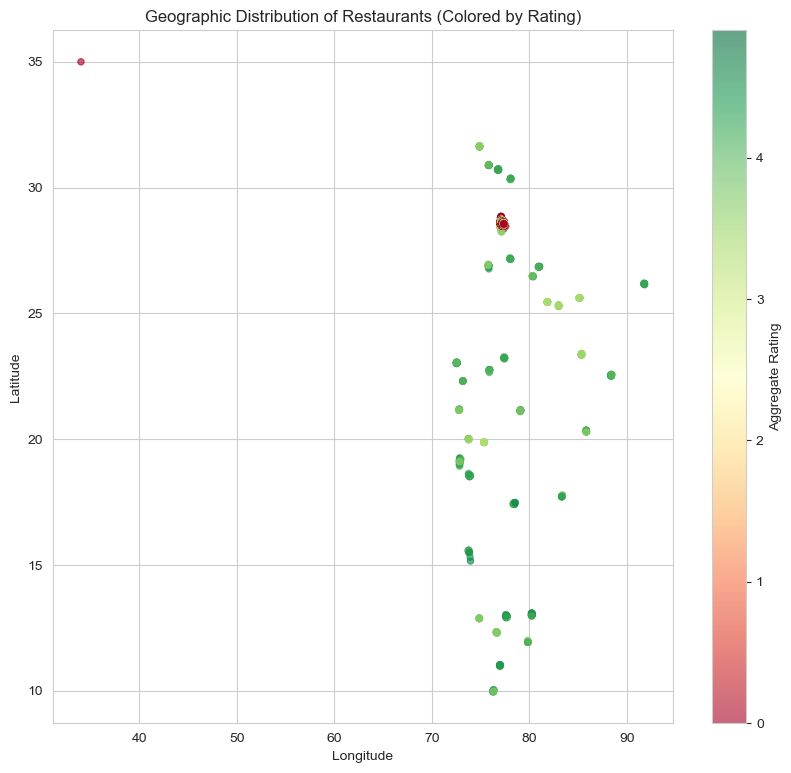

496 restaurants had missing coordinates and were excluded


In [64]:

geo_df = india_df[(india_df['Latitude'] != 0) & (india_df['Longitude'] != 0)]

plt.figure(figsize=(10,9))
scatter = plt.scatter(
    geo_df['Longitude'], geo_df['Latitude'],
    c=geo_df['Aggregate rating'], cmap='RdYlGn',
    alpha=0.6, s=20
)
plt.colorbar(scatter, label='Aggregate Rating')
plt.title('Geographic Distribution of Restaurants (Colored by Rating)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print(f"{(india_df.shape[0] - geo_df.shape[0])} restaurants had missing coordinates and were excluded")

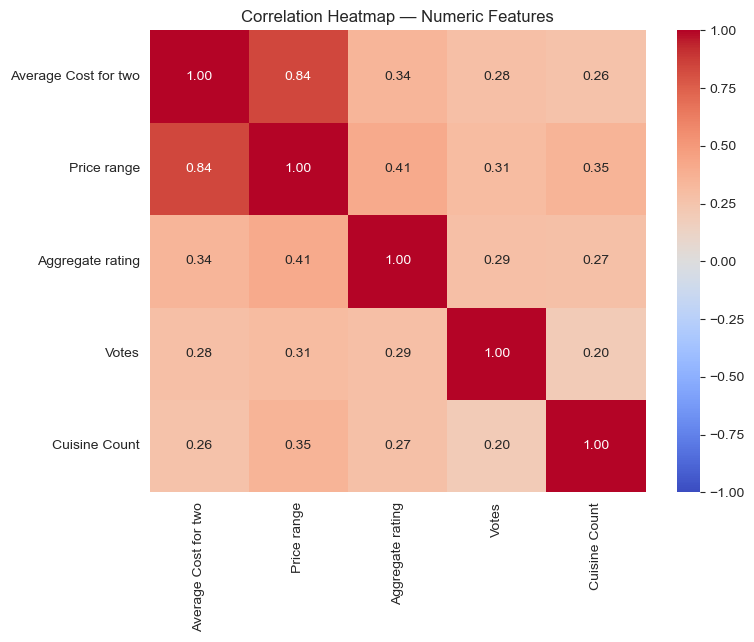

In [65]:
numeric_cols = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes', 'Cuisine Count']
corr = india_df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

## Key Insights

1. India makes up 90 % of the dataset (8652 of 9551 restaurants).
2. 24.7 % of restaurants have no rating yet; average rating among rated ones is 3.35.
3. The market is budget-skewed — 49.6 % of restaurants are in the cheapest price band.
4. Higher price range correlates with higher ratings (correlation ≈ 0.359).
5. North Indian is the most common cuisine, but Continental has a higher average rating.
6. Lucknow has the highest average rating among major cities.
7. The dataset is heavily concentrated in delhi.